# 第 8 讲 —— 神经值函数迭代

**异质性主体宏观经济学的计算方法**

孙振越 (Jeffrey Sun)


## 1. 准备工作


In [1]:
ENV["GKSwstype"] = "100"   # 无头绘图后端（用于 nbconvert）
using Pkg
Pkg.activate(@__DIR__)
Pkg.instantiate()

using HouseholdStages
using Flux
using Flux: Chain, Dense, swish, Adam, withgradient
using Printf
using Statistics
using LinearAlgebra
using Random: MersenneTwister, seed!
using Plots


  Activating project at `~/projects/teaching/ZJU Computational Macro 2026/tutorial_notebooks`


## 2. Krusell-Smith 模型设定

**Krusell-Smith** 模型就是在 Aiyagari 的基础上，为全要素生产率 $A$ 加入一个**总量**马尔可夫过程。

这意味着我们用于处理 MIT 冲击的那种``完美预见''方法不再适用。

当总量生产率 $Z_t$ 是随机的时，价格 $r_t, w_t$ 依赖于 $(Z_t, K_t)$。此时，如果家庭仅凭 $K_t$ 就能预期到 $K_{t+1}$，那么我们就可以把 $K_t$ 当作又一个特异性状态变量来处理。（这基本上就是所谓``分块递归''（block-recursive）模型所使用的技巧。）

但很遗憾，这里没有这样的好运气：在本例中，$K_{t+1}$ 是*所有*家庭储蓄选择的积分，而这些选择（由于异质性）依赖于整个财富分布 $\Lambda_t$。

因此，为了做出真正理性（即理性预期）的决策，主体自身的状态空间必须包含 $\Lambda_t$：
$$V(b, z; \Lambda, Z) = \max_{c, b'} u(c) + \beta\, \mathbb{E}[V(b', z'; \Lambda', Z') \mid z, Z].$$

但是，在 $\Lambda_t$ 的**所有可能取值**上构造网格是不可行的。我们需要某种降维方法。

这里我们介绍两种这样的方法。后一种是我自己的贡献：

- **§3 —— Krusell-Smith（1998）：** 假设主体只追踪一阶矩 $K_t$，并通过一个参数化的对数线性规则来预测 $K_{t+1}$。求解由此隐含的四维 VFI，进行模拟，再重新拟合该规则。近似加总（approximate aggregation）使这一方法奏效。
- **§4 —— CVIAYN：** 用一个神经网络直接参数化 $V_\theta(b, z, \Lambda, Z)$，该网络通过一个学习得到的广义矩来对完整分布 $\Lambda$ 加以条件化。舍弃总量运动规律（ALM），舍弃回归，转而针对外层贝尔曼残差进行训练。

本笔记本与上一份笔记本展示了求解同一个 **Krusell-Smith** 模型的两种方法。

在 K--S 模型上，nVFI 并不会显著优于 K--S 方法。事实上，K--S 方法表现得相当不错！但 nVFI 更具一般性。

我们先从构建 K--S 模型开始。

### 2.1 参数


In [2]:
@kwdef struct KSParams
    β::Float64 = 0.94
    γ::Float64 = 1.0
    α::Float64 = 0.36
    δ::Float64 = 0.025
    # 特异性生产率 z（失业 / 就业）
    z_grid::Vector{Float64} = [0.07, 1.0]
    Π_z::Matrix{Float64}    = [0.6   0.4;
                               0.05  0.95]
    # 总量全要素生产率 Z（坏 / 好）
    Z_vals::Vector{Float64} = [0.90, 1.10]
    Π_Z::Matrix{Float64}    = [0.875 0.125;
                               0.125 0.875]
    # 财富网格
    N_b::Int       = 80
    b_min::Float64 = 0.0
    b_max::Float64 = 80.0
    # K 网格（用于 K-S 四维 VFI；CVIAYN 不使用）
    N_K::Int       = 7
    K_min::Float64 = 5.0
    K_max::Float64 = 12.0
end


KSParams

### 2.2 价格与有效劳动

带全要素生产率 $Z$ 和有效劳动 $L$ 的 Cobb-Douglas 生产函数：
$$R(Z, K) = \alpha\, Z\, (K/L)^{\alpha-1} + 1 - \delta, \qquad w(Z, K) = (1-\alpha)\, Z\, (K/L)^\alpha.$$

有效劳动是 $z$ 在平稳分布下的均值。在本模型中它是常数，因为 $\Pi_z$ 不依赖于 $Z$。


In [3]:
function markov_stationary_mean(Π_z::AbstractMatrix, z_grid::AbstractVector)
    v = real.(eigvecs(Π_z')[:, end])
    return z_grid ⋅ (v ./ sum(v))
end

function ks_prices(K, Z, p::KSParams)
    L = markov_stationary_mean(p.Π_z, p.z_grid)
    R = p.α * Z * (K/L)^(p.α - 1) + 1 - p.δ
    w = (1 - p.α) * Z * (K/L)^p.α
    return (; R, w)
end


ks_prices (generic function with 1 method)

### 2.3 内层家庭链（3 个阶段）

期内模块与 Aiyagari 相同：`z_shock ∘ income ∘ savings`。


In [4]:
_u_crra(c, ::Val{1}) = log(c)
_u_crra(c, ::Val{1.0}) = log(c)
_u_crra(c, ::Val{σ}) where σ = (c^(1 - σ)) / (1 - σ)
u_crra(c, valσ::Val) = c < 0 ? -Inf : _u_crra(c, valσ)

"三阶段家庭链：z_shock ∘ income ∘ savings。价格从 env 读取。"
function ks_household(p::KSParams)
    # 定义布局：轴 1（财富）是连续的，轴 2（z）是离散的。
    layout = GriddedLayout(
        StateAxis(:wealth, continuous_grid(p.b_min, p.b_max; length=p.N_b, spacing=:log)),
        StateAxis(:z, p.z_grid),
    )

    # 定义这三个阶段。
    z_shock = MarkovStage(layout; axis=:z, transition_matrix=p.Π_z)

    income  = WealthChangeStage(layout; wealth_post=(cell; env) -> min(env.R * cell.wealth + env.w * cell.z, p.b_max)) # 将财富在 b_max 处截断

    savings = ConsumptionSavingsStage(layout; β=p.β, utility=(cell, c) -> u_crra(c, Val(p.γ)), monotone_search=:divide_conquer)

    # 构建家庭链并定义一个矩。
    hh = z_shock ∘ income ∘ savings
    return define_moments!(hh; K_supplied=at_end(integrand=:wealth, reduce=sum))
end


ks_household

### 2.4 $Z = 1$ 处的确定性 Aiyagari 稳态

在加入总量不确定性之前，先用 tatonnement 求出 $Z = 1$ 处的确定性稳态 $\bar K$。


In [5]:
"""用对 K 二分法求给定 Z 处的确定性 Aiyagari 稳态。

均衡满足 A(K) = K，其中 A 是在由 K 隐含的价格下的家庭资产供给。
之所以采用二分法，是因为本校准恰好落在棘手的 βR≈1 临界点附近。
A(K) 关于 K 单调递减，故 K 唯一，并被 [K_lo, K_hi] 所夹。"""
function aiyagari_steady_state_at_Z(p::KSParams; Z=1.0, K_lo=5.0, K_hi=12.0, rtol=3e-3, maxiter=30, verbosity=0)
    hh = ks_household(p)
    V, Λ = nothing, nothing
    function supply(K)                       # 家庭资产供给 A(K)，热启动
        res = solve_steady_state_given_env!(hh, make_env(hh; ks_prices(K, Z, p)...);
                                            V_init=V, Λ_init=Λ, lambda_tol=1e-7, lambda_maxiter=2_000_000)
        V = res.V; Λ = res.Λ
        return res.moments.K_supplied
    end
    lo, hi = K_lo, K_hi
    (supply(lo) - lo > 0 && supply(hi) - hi < 0) ||
        error("aiyagari_steady_state_at_Z: [K_lo, K_hi] = [$K_lo, $K_hi] does not bracket A(K)=K")
    K = (lo + hi) / 2; iters = 0
    for i in 1:maxiter
        K = (lo + hi) / 2
        f = supply(K) - K
        iters = i
        verbosity >= 1 && @printf "  bisect %2d: K = %.4f,  A(K) − K = %+.4f\n" i K f
        abs(f) / K < rtol && break
        f > 0 ? (lo = K) : (hi = K)          # A(K)−K 递减 ⇒ 移动右边界
    end
    return (; K, V, Λ, iters)
end


aiyagari_steady_state_at_Z

## 3. 神经值函数迭代（CVIAYN）


In [6]:
p = KSParams()

const N_z = length(p.z_grid)
const N_Z = length(p.Z_vals)

# 预先构建一次 (2, N_b * N_z) 的特征矩阵。每一列是某个
# 单元的归一化 (b, z) 坐标。
function build_hh_feat(p::KSParams)
    b_norm = collect(range(0f0, 1f0; length=p.N_b))
    z_norm = collect(range(0f0, 1f0; length=length(p.z_grid)))
    feat = zeros(Float32, 2, p.N_b * length(p.z_grid))
    col = 1
    for j in 1:length(p.z_grid), i in 1:p.N_b
        feat[1, col] = b_norm[i]
        feat[2, col] = z_norm[j]
        col += 1
    end
    return feat
end

const HH_FEAT = build_hh_feat(p)
const N_CELLS = size(HH_FEAT, 2)

# 为每个 Z_idx 预先构建独热（one-hot）的 Z 行，形状为 (N_Z, N_CELLS)，
# 以便在 V_post 中可以直接与 (mid, N_CELLS) 的隐藏特征作 vcat。
const Z_ROWS = [repeat(Float32.(1:N_Z .== Z_idx), 1, N_CELLS) for Z_idx in 1:N_Z]

# 财富网格及其间距，供单调-凹的 V_θ 构造使用。
const B_GRID = Float32.(axisvalues(input_layout(ks_household(p)).axes[1]))
const DB     = reshape(diff(B_GRID), p.N_b - 1, 1)



79×1 Matrix{Float32}:
 0.057202153
 0.06047424
 0.06393349
 0.067590624
 0.071456954
 0.07554445
 0.07986575
 0.08443427
 0.089264035
 0.09437019
 ⋮
 2.8085022
 2.9691582
 3.1389961
 3.3185577
 3.5083847
 3.709072
 3.9212341
 4.145546
 4.382675

In [7]:
# ── 值网络 V_θ(Λ, Z)：括号锚定（bracket-anchor）参数化 ──────────────
# 为了获得最大的稳定性，vnet 被构建为一个介于两端之间的*控制变量*，
# 两端是在 K(Λ_ss) 处、对应两个永久 Z 取值的稳态值函数
# V̄_bad ≤ V̄_good：
#
#     V_θ(Λ, Z) = V̄_bad + s_Z .* (V̄_good − V̄_bad),     s_Z ∈ [0, 1]
#
# 网络输出 s_Z，它表示在括号区间内所处的位置。
# 于是当 s ∈ [0,1] 时，括号 V̄_bad ≤ V_θ ≤ V̄_good 在构造上自然成立。

abstract type AbstractVNet end

using Flux: sigmoid, softplus

struct BracketVNet{A,P,G,B,Z,M} <: AbstractVNet
    pop_agg   :: A
    V_pre     :: P
    gm_post   :: G
    base_head :: B
    gap_head  :: Z
    Vbar_bad  :: M    # (N_b, N_z) 常量
    Vbar_diff :: M    # (N_b, N_z) 常量，= V̄_good − V̄_bad ≥ 0
end
Flux.@layer BracketVNet
Flux.trainable(m::BracketVNet) = (; m.pop_agg, m.V_pre, m.gm_post, m.base_head, m.gap_head)

"""
构造一个括号锚定值网络。`Vbar_bad`、`Vbar_good` 是在 K(Λ_ss) 处、
对应永久 Z 的固定价格稳态值函数。轻量级的``头部''（heads）被初始化为
零，使得 s≈0.5。也就是说，我们从括号区间的中点出发。
"""
function BracketVNet(Vbar_bad, Vbar_good; gm_dim=16, mid=32, seed=9483)
    seed!(seed)
    pop_agg   = Chain(Dense(2=>mid,swish), Dense(mid=>mid,swish), Dense(mid=>gm_dim))
    V_pre     = Chain(Dense(2=>mid,swish), Dense(mid=>mid,swish), Dense(mid=>mid,swish))
    gm_post   = Chain(Dense(gm_dim=>mid), Dense(mid=>mid,swish))
    base_head = Chain(Dense(mid=>mid,swish), Dense(mid=>1))
    gap_head  = Chain(Dense(mid=>mid,swish), Dense(mid=>1))
    base_head.layers[end].weight .= 0f0; base_head.layers[end].bias .= 0f0   # s≈0.5
    gap_head.layers[end].weight  .= 0f0; gap_head.layers[end].bias  .= -2f0  # softplus(-2)≈0.13
    Vd = Float32.(Vbar_good .- Vbar_bad)
    BracketVNet(pop_agg, V_pre, gm_post, base_head, gap_head, Float32.(Vbar_bad), Vd)
end

function (net::BracketVNet)(Λ::AbstractMatrix, Z_idx::Int, p)
    gm   = net.pop_agg(HH_FEAT) * Float32.(vec(Λ))        # (gm_dim,)
    h    = net.V_pre(HH_FEAT) .+ net.gm_post(gm)          # (mid, N_CELLS)
    base = reshape(net.base_head(h), p.N_b, N_z)          # (N_b, N_z)
    s = if Z_idx == 1                                     # 坏的总量状态
        sigmoid.(base)
    else                                                 # 好的：s_good ≥ s_bad
        gap = reshape(net.gap_head(h), p.N_b, N_z)
        sigmoid.(base .+ softplus.(gap))
    end
    return net.Vbar_bad .+ s .* net.Vbar_diff
end



### 3.1 在 $V_\theta$ 下的一次内层求解

给定一个总量状态 $(\Lambda, Z)$：

1. 计算 $V_\theta(\Lambda, Z)$，得到一个由 $V^{\mathrm{end}}$ 值构成的 `N_b × N_z` 数组。
2. 在价格 $(R, w) = $ `ks_prices(K(Λ), Z, p)` 处构建 `env`，其中 $K(\Lambda) = \int b\, d\Lambda$。
3. 在 `ks_household` 中向后迭代，得到 $V^{\mathrm{start}}$。

这就是**期内求解器** $\Phi_V$。


In [8]:
"针对二维 (b, z) 分布的财富积分。"
function integrate_K(hh, Λ::AbstractMatrix)
    b_grid = axisvalues(input_layout(hh).axes[1])
    return sum(Λ[i, j] * b_grid[i] for i in axes(Λ, 1), j in axes(Λ, 2))
end

"给定 (Λ, Z) 与 V_θ，在家庭模块中向后迭代。"
function inner_solve_backward(hh, vnet, Λ::AbstractMatrix, Z_idx::Int, p::KSParams)
    V_end = Float64.(vnet(Λ, Z_idx, p))
    env   = make_env(hh; ks_prices(integrate_K(hh, Λ), p.Z_vals[Z_idx], p)...)
    return backward!(hh, V_end, env)
end

ss = aiyagari_steady_state_at_Z(p; verbosity=1)
K_bar, Λ_ss, V_ss = ss.K, ss.Λ, ss.V
hh  = ks_household(p)
K_ss = integrate_K(hh, Λ_ss)
@printf "Deterministic Aiyagari SS: K_bar = %.4f,  K_ss = K(Λ_ss) = %.4f\n" K_bar K_ss


  bisect  1: K = 8.5000,  A(K) − K = -3.6213
  bisect  2: K = 6.7500,  A(K) − K = +17.6769
  bisect  3: K = 7.6250,  A(K) − K = +1.0257
  bisect  4: K = 8.0625,  A(K) − K = -0.2134
  bisect  5: K = 7.8438,  A(K) − K = +0.0198
Deterministic Aiyagari SS: K_bar = 7.8438,  K_ss = K(Λ_ss) = 7.8636


### 3.0 永久-$Z$ 值括号 $\bar V(Z)$

在构建 vnet 之前，我们必须求解两个**永久-$Z$ 固定价格稳态**，二者都处于共同的资本 $K_{\mathrm{ss}} = K(\Lambda_{\mathrm{ss}})$ 处。

对每个总量状态 $Z$，我们将价格固定在 $(R, w) = $ `ks_prices(K_ss, Z_vals[Z])`，并在这些价格和该 $Z$ 取值下求解*内层*家庭的稳态。

我们称这些值函数为 $\bar V_{\mathrm{bad}}$ 和 $\bar V_{\mathrm{good}}$。它们是 `N_b x N_z` 数组，应当**逐点**满足 $\bar V_{\mathrm{bad}} \le \bar V_{\mathrm{good}}$。


In [9]:
"""
在共同的 K_ss 处、对应永久-Z 的固定价格稳态值函数。
"""
function compute_Vbar(hh, K_ss, p)
    V̄ = [Float64.(solve_steady_state_given_env!(hh, make_env(hh; ks_prices(K_ss, p.Z_vals[Z], p)...);
                  V_init=nothing, Λ_init=nothing, lambda_tol=1e-7, lambda_maxiter=2_000_000).V) for Z in 1:N_Z]
    return (V̄[1], V̄[2])
end

println("Solving permanent-Z value brackets V̄(Z) at K_ss = $(round(K_ss, digits=4))...")
Vbar_bad, Vbar_good = compute_Vbar(hh, K_ss, p)
@printf "V̄_bad  ∈ [%.2f, %.2f]\n" minimum(Vbar_bad)  maximum(Vbar_bad)
@printf "V̄_good ∈ [%.2f, %.2f]\n" minimum(Vbar_good) maximum(Vbar_good)
@printf "ordered (V̄_good ≥ V̄_bad everywhere): %s   (min gap = %+.4f)\n" all(Vbar_good .>= Vbar_bad) minimum(Vbar_good .- Vbar_bad)

# 演示：在初始化时构建网络（位于括号中点 —— 无需预训练）。
vnet = BracketVNet(Vbar_bad, Vbar_good)
V0 = vnet(Λ_ss, 1, p)
@printf "\nBracketVNet at init (Λ_ss, Z=bad): shape = %s, range = [%.3f, %.3f]\n" string(size(V0)) minimum(V0) maximum(V0)
V_start_demo = inner_solve_backward(hh, vnet, Λ_ss, 1, p)
@printf "Inner backward at (Λ_ss, Z=bad): V_start shape = %s, range = [%.3f, %.3f]\n" string(size(V_start_demo)) minimum(V_start_demo) maximum(V_start_demo)


Solving permanent-Z value brackets V̄(Z) at K_ss = 7.8636...
V̄_bad  ∈ [-2.19, 27.26]
V̄_good ∈ [1.79, 31.05]
ordered (V̄_good ≥ V̄_bad everywhere): true   (min gap = +3.5974)

BracketVNet at init (Λ_ss, Z=bad): shape = (80, 2), range = [-0.197, 29.157]
Inner backward at (Λ_ss, Z=bad): V_start shape = (80, 2), range = [-0.325, 29.157]


### 3.2 前瞻算子 $\mathcal{L} V_\theta$

对单个采样得到的 $\Lambda^{\mathrm{start}}_i$，其总量指标为 $Z_i$：

1. 计算 $V_\theta(\Lambda^{\mathrm{start}}_i, Z_i)$，得到 $V^{\mathrm{end}}$ —— 即主体当前对期末延续值的信念。
2. 将 $\Lambda^{\mathrm{start}}_i$ 通过 $\Phi$ 向前推进一期，得到 $\Lambda^{\mathrm{end}}_i$。
3. 对每个下一期总量状态 $Z_{\mathrm{next}}$，在 $(\Lambda^{\mathrm{end}}_i, Z_{\mathrm{next}})$ 处运行 $\Phi_V$，得到 $V^{\mathrm{start}}_{\mathrm{next}}$。
4. 用 $\Pi_Z[Z_i, \cdot]$ 对 $Z_{\mathrm{next}}$ 求期望。

在本设定中，$\Omega(\Lambda^{\mathrm{end}}, Z')$ 是恒等映射 —— 总量冲击 $Z'$ 影响下一期价格，但在期界处并不影响 $\Lambda$。因此 $\Lambda^{\mathrm{start}}_{i+1} = \Lambda^{\mathrm{end}}_i$。其结果就是**前瞻标签** $\widehat{V}^{\mathrm{end}}_i \equiv (\mathcal{L} V_\theta)(\Lambda^{\mathrm{start}}_i, Z_i)$。


In [10]:
"计算前瞻标签 LV_θ(Λ_start, Z)。返回 V_end_label 与 Λ_end。"
function lookahead(hh, vnet, Λ_start::AbstractMatrix, Z_idx::Int, p::KSParams)
    V_end_now = Float64.(vnet(Λ_start, Z_idx, p))
    env_now   = make_env(hh; ks_prices(integrate_K(hh, Λ_start), p.Z_vals[Z_idx], p)...)
    backward!(hh, V_end_now, env_now)                  # 落实储蓄策略
    Λ_end = forward!(hh, Λ_start)

    V_end_label = zeros(Float64, p.N_b, length(p.z_grid))
    for Z_next in 1:N_Z
        V_start_next = inner_solve_backward(hh, vnet, Λ_end, Z_next, p)
        V_end_label .+= p.Π_Z[Z_idx, Z_next] .* V_start_next
    end
    return (; V_end_label, Λ_end)
end


lookahead

### 3.3 外层贝尔曼残差损失

对一批样本 $\{(\Lambda^{\mathrm{start}}_i, Z_i)\}$，先在 `withgradient` *之外*计算一次前瞻标签 $\widehat{V}^{\mathrm{end}}_i$，然后以均方意义将 $V_\theta$ 拟合到它。

这是一种``半梯度''（semi-gradient）处理：我们不通过 $\Phi$ 求导。


In [11]:
"在每个样本上运行前瞻算子。返回由 (Λ, Z_idx, target) 元组构成的向量。"
function build_targets(hh, vnet::AbstractVNet, batch, p::KSParams)
    targets = NamedTuple{(:Λ, :Z_idx, :target), Tuple{Matrix{Float64}, Int, Matrix{Float32}}}[]
    for (Λ_start, Z_idx) in batch
        out = lookahead(hh, vnet, Λ_start, Z_idx, p)
        push!(targets, (; Λ=copy(Λ_start), Z_idx, target=Float32.(out.V_end_label)))
    end
    return targets
end

"在一批 (Λ, Z, target) 元组上计算朴素的均方外层贝尔曼残差。"
function bellman_residual_loss(vnet::AbstractVNet, targets, p::KSParams)
    L = 0f0
    for (Λ, Z_idx, target) in targets
        pred = vnet(Λ, Z_idx, p)
        L   += sum((pred .- target).^2) / length(pred)
    end
    return L / length(targets)
end

"""
外层贝尔曼残差（方差归一化）
"""
function normalized_residual(vnet::AbstractVNet, targets, p::KSParams)
    msetot = 0.0; varV = 0.0
    for (Λ, Z_idx, target) in targets
        pred = vnet(Λ, Z_idx, p)
        msetot += sum((pred .- target).^2) / length(pred)
        w  = Float64.(Λ) ./ sum(Λ) # 人口权重，求和为 1
        μ  = sum(w .* target)
        # 偏差修正的加权方差。
        varV += sum(w .* (target .- μ).^2) / (1 - sum(w.^2))
    end
    return (msetot / length(targets)) / (varV / length(targets))
end


normalized_residual

### 3.4 用 MCMC 采样 $\Lambda^{\mathrm{start}}$

在*当前*的 $V_\theta$ 下模拟模型，丢弃 burn-in，再做子采样。

注意，尽管 $Z$ 的取值是外生的，总量状态却依赖于 $V_\theta$。因此随着 $V_\theta$ 改进，总量状态的分布会发生变化，并逐渐接近真实模型的遍历分布。


In [12]:
"从总量马尔可夫链中采样 Z_{t+1} | Z_t。"
function sample_Z(Z_idx, Π_Z, rng)
    u = rand(rng)
    s = 0.0
    for j in eachindex(view(Π_Z, Z_idx, :))
        s += Π_Z[Z_idx, j]
        u <= s && return j
    end
    return size(Π_Z, 2)
end

"在已实现的 (Λ_t, Z_t) 处、在 V_θ 下向前模拟一期。"
function sim_one_step(hh, vnet::AbstractVNet, Λ::AbstractMatrix, Z_idx::Int, p::KSParams)
    V_end = Float64.(vnet(Λ, Z_idx, p))
    env   = make_env(hh; ks_prices(integrate_K(hh, Λ), p.Z_vals[Z_idx], p)...)
    backward!(hh, V_end, env)
    return forward!(hh, Λ)
end

"沿 V_θ 所诱导的遍历路径，对 (Λ_start, Z) 进行 MCMC 式采样。"
function sample_ergodic(hh, vnet::AbstractVNet, p::KSParams; T=800, burn=400, every=4, rng=MersenneTwister(8421))
    Λ     = copy(Λ_ss)
    Z_idx = 1
    batch = Tuple{Matrix{Float64}, Int}[]
    for t in 1:T
        Λ     = sim_one_step(hh, vnet, Λ, Z_idx, p)
        Z_idx = sample_Z(Z_idx, p.Π_Z, rng)
        if t > burn && (t - burn) % every == 0
            push!(batch, (copy(Λ), Z_idx))
        end
    end
    return batch
end


sample_ergodic

### 3.5 计算 $V$ 括号（替代预训练）


In [13]:
# 括号锚定网络无需预训练，因为按设计它已初始化在括号中点处。
println("Solving deterministic Aiyagari SS at each Z (reference curves for §7 plot only)...")
V_ss_per_Z = [aiyagari_steady_state_at_Z(p; Z=Zv).V for Zv in p.Z_vals]
for (i, Zv) in enumerate(p.Z_vals)
    @printf "  Z=%.2f: V range = [%.2f, %.2f]\n" Zv minimum(V_ss_per_Z[i]) maximum(V_ss_per_Z[i])
end


Solving deterministic Aiyagari SS at each Z (reference curves for §7 plot only)...
  Z=0.90: V range = [-2.91, 28.43]
  Z=1.10: V range = [2.39, 29.82]


### 3.6 一次 Howard 式改进

我们采用``**冻结目标**''（Frozen-target）的拟合值迭代（FVI）进行采样。每一个*外层*步骤：

1. 在当前 $V_\theta$ 下，于一个大批量上构建一批前瞻标签 $\mathcal{L} V_\theta$。
2. 将在线网络**完全**拟合到这些固定目标上。由于样本固定且不依赖于在线的 $V_\theta$，这基本上可以收敛到几乎完美的拟合（$\sim 10^{-5}$）。
3. 从步骤 1 重复。

为了获得一些额外的稳定性，我们还使用一个``形状惩罚''来保持 $V_\theta$ 关于 $b$ 和 $z$ 单调。


In [15]:
# 构建样本缓冲区 #
#---------------------#
"""
对 Λ 施加乘性噪声扰动（再归一化），用于扩大回放缓冲区的覆盖面。
"""
function perturb_Λ(Λ, σ, rng)
    Λp = Λ .* (1 .+ σ .* randn(rng, size(Λ)))
    Λp = max.(Λp, 0f0)
    return Λp ./ sum(Λp)
end

"""
刷新回放缓冲区：加入当前网络下的同策略（on-policy）遍历状态，以及围绕这些
状态的 Λ-云扰动，并以 `cap` 为上限（FIFO）。覆盖面广 + 相关性低
⇒ 更低的采样噪声下限。
"""
function refresh_buffer!(buffer, net, hh, p, rng; T=300, burn=150, every=3, n_cloud=40, σ=0.08, cap=4000)
    erg = sample_ergodic(hh, net, p; T, burn, every, rng=MersenneTwister(rand(rng, UInt32)))
    append!(buffer, erg)
    # 围绕若干遍历锚点（+ Λ_ss）的 Λ-云，用于覆盖偏离路径的区域
    anchors = isempty(erg) ? [(copy(Λ_ss), 1), (copy(Λ_ss), 2)] : erg
    for _ in 1:n_cloud
        (Λ0, _) = anchors[rand(rng, 1:length(anchors))]
        push!(buffer, (perturb_Λ(Float64.(Λ0), σ, rng), rand(rng, 1:N_Z)))
    end
    if length(buffer) > cap
        deleteat!(buffer, 1:(length(buffer)-cap))
    end
    return buffer
end

# 冻结目标拟合值迭代 #
#--------------------------------------#
# 在一组 (Λ,Z) 状态上施加软性的``关于 b 单调''（+ 关于 z 单调）惩罚。
"""
在一组 (Λ,Z) 状态上施加软性形状惩罚，促使 V_θ 关于 b 以及关于自身 z 单调。
返回的是逐状态的平均值；以 λ_mono 缩放后并入损失。
"""
function shape_penalty(net, states, p)
    pen = 0f0
    for (Λ, Z) in states
        V = net(Λ, Z, p)
        pen += sum(Flux.relu.(-diff(V; dims=1)))            # 关于 b 单调：惩罚 V[i+1] < V[i]
        pen += sum(Flux.relu.(.-(V[:, 2:end] .- V[:, 1:end-1])))  # 跨列的关于 z 单调
    end
    return pen / length(states)
end

"""
冻结目标拟合值迭代。每个外层步骤冻结 V_θ，在一个大样本批量上构建前瞻
目标 LV_θ，然后将在线网络完全拟合到这些固定目标上。
"""
function train_fvi!(net, hh, p; n_outer=80, n_inner=40, batch_size=200,
                    lr0=3e-3, lr1=3e-4, λ_mono=0.0, seed=1234, eval_fn=nothing, eval_every=10, verbose=true, live=false)
    rng    = MersenneTwister(seed)
    buffer = Tuple{Matrix{Float64},Int}[]
    opt    = Flux.setup(Adam(Float32(lr0)), net)
    hist   = Float64[]
    for outer in 1:n_outer
        refresh_buffer!(buffer, net, hh, p, rng)
        idx   = rand(rng, 1:length(buffer), min(batch_size, length(buffer)))
        batch = buffer[idx]
        targets = build_targets(hh, net, batch, p)          # ℒ(冻结网络)，本外层步骤内固定

        # 惩罚状态：批量的一个子样本 + Λ_ss（检查点），两个 Z 都包含
        pen_states = vcat(batch[1:min(end,30)], [(copy(Λ_ss),1), (copy(Λ_ss),2)])

        # 在各外层步骤间对 lr 退火（余弦）
        frac = (outer-1)/max(n_outer-1,1)
        lr   = Float32(lr1 + 0.5*(lr0-lr1)*(1+cos(π*frac)))
        Flux.adjust!(opt, lr)

        local loss

        # 训练网络
        for _ in 1:n_inner
            loss, gs = withgradient(net) do m
                L = bellman_residual_loss(m, targets, p)
                λ_mono > 0 ? L + Float32(λ_mono)*shape_penalty(m, pen_states, p) : L
            end
            Flux.update!(opt, net, gs[1])
        end

        # 保存残差并报告
        r = normalized_residual(net, targets, p)
        push!(hist, r)
        if verbose && (outer==1 || outer % eval_every == 0)
            @printf("  outer %3d/%3d  lr=%.1e  fit-resid=%.3e  |buf|=%d\n", outer, n_outer, lr, r, length(buffer))
            eval_fn !== nothing && eval_fn(net, outer)
        end

        # 展示损失改进的酷炫可视化
        if live && (outer == 1 || outer % eval_every == 0) && isdefined(Main, :IJulia)
            Main.IJulia.clear_output(true)
            display(plot(hist; yaxis=:log, lw=2, marker=:circle, ms=3, color=:firebrick, label="",
                         xlabel="outer iteration", ylabel="fit-residual  MSE / var(V)",
                         title=@sprintf("Frozen-target FVI — training live (outer %d/%d,  resid %.2e)",
                                        outer, n_outer, r),
                         size=(720, 360)))
        end
    end
    return hist
end


train_fvi!

### 3.7 运行训练

构建括号锚定网络并运行冻结目标 FVI。训练只需**几分钟**，并在通过一大批一致性检验（sanity check）的同时，将 Krusell–Smith 的外层贝尔曼残差大约改进 $8\times$。

注意：胜过 Krusell–Smith 并不是重点。这是一个不错的检验，但重点在于这是一种非常一般的方法，可以应用于一大类模型。


In [16]:
net  = BracketVNet(Vbar_bad, Vbar_good)
@time hist = train_fvi!(net, hh, p; n_outer=40, n_inner=40, batch_size=150, lr0=3e-3, λ_mono=1e-2, live=true, eval_every=3)

vnet       = net                # 下游 §4/§5/§6/§7 各单元基于 `vnet` 分派
train_hist = hist               # §3.8 / §7 训练曲线单元读取 `train_hist`
@printf "\nFinal outer Bellman residual (normalized, research-comparable): %.4e\n" hist[end]


  outer   1/ 40  lr=3.0e-03  fit-resid=8.022e-04  |buf|=90
  outer   3/ 40  lr=3.0e-03  fit-resid=1.246e-03  |buf|=270
  outer   6/ 40  lr=2.9e-03  fit-resid=1.359e-04  |buf|=540
  outer   9/ 40  lr=2.7e-03  fit-resid=1.534e-04  |buf|=810
  outer  12/ 40  lr=2.5e-03  fit-resid=1.494e-04  |buf|=1080
  outer  15/ 40  lr=2.2e-03  fit-resid=1.686e-04  |buf|=1350
  outer  18/ 40  lr=1.9e-03  fit-resid=1.654e-04  |buf|=1620
  outer  21/ 40  lr=1.6e-03  fit-resid=1.542e-04  |buf|=1890
  outer  24/ 40  lr=1.3e-03  fit-resid=1.823e-04  |buf|=2160
  outer  27/ 40  lr=9.7e-04  fit-resid=6.088e-05  |buf|=2430
  outer  30/ 40  lr=7.1e-04  fit-resid=1.182e-04  |buf|=2700
  outer  33/ 40  lr=5.1e-04  fit-resid=6.195e-05  |buf|=2970
  outer  36/ 40  lr=3.7e-04  fit-resid=8.635e-05  |buf|=3240
  outer  39/ 40  lr=3.0e-04  fit-resid=5.612e-05  |buf|=3510
463.208823 seconds (464.04 M allocations: 252.835 GiB, 16.61% gc time, 10.22% compilation time: <1% of which was recompilation)

Final outer Bellman re

### 3.8 解读训练曲线

`train_fvi!` 在每个*外层*步骤结束时（即网络已完全拟合到该外层冻结目标之后）记录方差归一化的贝尔曼残差。


Final in-sample fit-residual (frozen-target FVI): 5.7932e-05  (held-out nVFI-vs-K-S comparison is in §6)


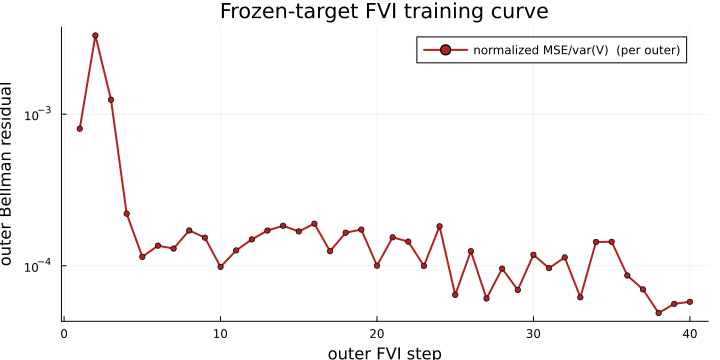

In [16]:
@printf "Final in-sample fit-residual (frozen-target FVI): %.4e  (held-out nVFI-vs-K-S comparison is in §6)\n" train_hist[end]

plt = plot(train_hist; yaxis=:log, lw=2, color=:firebrick, marker=:circle, ms=3,
           label="normalized MSE/var(V)  (per outer)",
           xlabel="outer FVI step", ylabel="outer Bellman residual",
           title="Frozen-target FVI training curve", size=(720, 360), legend=:topright)
plt


所报告的残差是**方差归一化**的贝尔曼残差 $\overline{\mathrm{MSE}}/\operatorname{Var}(V)$ —— 它是无量纲的，因此可跨不同的值函数尺度进行比较，并可直接与 §6 中的 Krusell–Smith 基准相对照。（冻结目标 FVI 在内部优化的是朴素的均方残差；归一化版本仅用于报告。）
